# Project Python Foundations: FoodHub Data Analysis

### Context

The number of restaurants in New York is increasing day by day. Lots of students and busy professionals rely on those restaurants due to their hectic lifestyles. Online food delivery service is a great option for them. It provides them with good food from their favorite restaurants. A food aggregator company FoodHub offers access to multiple restaurants through a single smartphone app.

The app allows the restaurants to receive a direct online order from a customer. The app assigns a delivery person from the company to pick up the order after it is confirmed by the restaurant. The delivery person then uses the map to reach the restaurant and waits for the food package. Once the food package is handed over to the delivery person, he/she confirms the pick-up in the app and travels to the customer's location to deliver the food. The delivery person confirms the drop-off in the app after delivering the food package to the customer. The customer can rate the order in the app. The food aggregator earns money by collecting a fixed margin of the delivery order from the restaurants.

### Objective

The food aggregator company has stored the data of the different orders made by the registered customers in their online portal. They want to analyze the data to get a fair idea about the demand of different restaurants which will help them in enhancing their customer experience. Suppose you are hired as a Data Scientist in this company and the Data Science team has shared some of the key questions that need to be answered. Perform the data analysis to find answers to these questions that will help the company to improve the business.

### Data Description

The data contains the different data related to a food order. The detailed data dictionary is given below.

### Data Dictionary

* order_id: Unique ID of the order
* customer_id: ID of the customer who ordered the food
* restaurant_name: Name of the restaurant
* cuisine_type: Cuisine ordered by the customer
* cost_of_the_order: Cost of the order
* day_of_the_week: Indicates whether the order is placed on a weekday or weekend (The weekday is from Monday to Friday and the weekend is Saturday and Sunday)
* rating: Rating given by the customer out of 5
* food_preparation_time: Time (in minutes) taken by the restaurant to prepare the food. This is calculated by taking the difference between the timestamps of the restaurant's order confirmation and the delivery person's pick-up confirmation.
* delivery_time: Time (in minutes) taken by the delivery person to deliver the food package. This is calculated by taking the difference between the timestamps of the delivery person's pick-up confirmation and drop-off information

### Let us start by importing the required libraries

In [1]:
# Installing the libraries with the specified version.
!pip install numpy==1.25.2 pandas==1.5.3 matplotlib==3.7.1 seaborn==0.13.1 -q --user

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 38.4 MB/s eta 0:00:00
  Installing build dependencies ... done
  error: subprocess-exited-with-error
  
  × Getting requirements to build wheel did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Getting requirements to build wheel ... error
error: subprocess-exited-with-error

× Getting requirements to build wheel did not run successfully.
│ exit code: 1
╰─> See above for output.

note: This error originates from a subprocess, and is likely not a problem with pip.


**Note**:
- After running the above cell, kindly restart the runtime (for Google Colab) or notebook kernel (for Jupyter Notebook), and run all cells sequentially from the next cell.
- On executing the above line of code, you might see a warning regarding package dependencies. This error message can be ignored as the above code ensures that all necessary libraries and their dependencies are maintained to successfully execute the code in ***this notebook***.

In [2]:
# import libraries for data manipulation
import numpy as np
import pandas as pd

# import libraries for data visualization
import matplotlib.pyplot as plt
import seaborn as sns

### Understanding the structure of the data

In [3]:
# uncomment and run the below code snippets if the dataset is present in the Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
df = pd.read_csv('/content/drive/MyDrive/Python_Course/Project/Project 1 Food Hub/foodhub_order.csv') # Write your code here to read the data

In [5]:
# Write your code here to view the first 5 rows
df.head()

,order_id,customer_id,restaurant_name,cuisine_type,cost_of_the_order,day_of_the_week,rating,food_preparation_time,delivery_time
0,1477147,337525,Hangawi,Korean,30.75,Weekend,Not given,25,20
1,1477685,358141,Blue Ribbon Sushi Izakaya,Japanese,12.08,Weekend,Not given,25,23
2,1477070,66393,Cafe Habana,Mexican,12.23,Weekday,5,23,28
3,1477334,106968,Blue Ribbon Fried Chicken,American,29.20,Weekend,3,25,15
4,1478249,76942,Dirty Bird to Go,American,11.59,Weekday,4,25,24


### **Question 1:** How many rows and columns are present in the data? [0.5

1.   List item
2.   List item

mark]

In [6]:
# Write your code here
df.shape

(1898, 9)

#### Observations:


### **Question 2:** What are the datatypes of the different columns in the

1.   List item
2.   List item

dataset? (The info() function can be used) [0.5 mark]

In [7]:
# Write your code here
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1898 entries, 0 to 1897
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   order_id               1898 non-null   int64  
 1   customer_id            1898 non-null   int64  
 2   restaurant_name        1898 non-null   object 
 3   cuisine_type           1898 non-null   object 
 4   cost_of_the_order      1898 non-null   float64
 5   day_of_the_week        1898 non-null   object 
 6   rating                 1898 non-null   object 
 7   food_preparation_time  1898 non-null   int64  
 8   delivery_time          1898 non-null   int64  
dtypes: float64(1), int64(4), object(4)
memory usage: 133.6+ KB


#### Observations: There are 4 columns with int64, 4 with object and 1 with float datatype.



### **Question 3:** Are there any missing values in the data? If yes, treat them using an appropriate method. [1 mark]

In [8]:
# Write your code here
df.isnull().sum()

,0
order_id,0
customer_id,0
restaurant_name,0
cuisine_type,0
cost_of_the_order,0
day_of_the_week,0
rating,0
food_preparation_time,0
delivery_time,0


In [9]:
#Order with rating as "Not given"

print("Order with rating as Not given:",df[df['rating']=='Not given'].count().get('order_id'))

Order with rating as Not given: 736


#### Observations: There are no column with missing values. Also, the Order count for which there is no rating is 736

1.   List item
2.   List item




### **Question 4:** Check the statistical summary of the data. What is the minimum, average, and maximum time it takes for food to be prepared once an order is placed? [2 marks]

In [10]:
# Write your code here
df.describe()

,order_id,customer_id,cost_of_the_order,food_preparation_time,delivery_time
count,1.898000e+03,1898.000000,1898.000000,1898.000000,1898.000000
mean,1.477496e+06,171168.478398,16.498851,27.371970,24.161749
std,5.480497e+02,113698.139743,7.483812,4.632481,4.972637
min,1.476547e+06,1311.000000,4.470000,20.000000,15.000000
25%,1.477021e+06,77787.750000,12.080000,23.000000,20.000000
50%,1.477496e+06,128600.000000,14.140000,27.000000,25.000000
75%,1.477970e+06,270525.000000,22.297500,31.000000,28.000000
max,1.478444e+06,405334.000000,35.410000,35.000000,33.000000


In [11]:
min_time  = df['food_preparation_time'].min()
avg_time  = df['food_preparation_time'].mean()
max_time  = df['food_preparation_time'].max()

print("Minimum prep time:", min_time)
print("Average prep time:", avg_time)
print("Maximum prep time:", max_time)

Minimum prep time: 20
Average prep time: 27.371970495258168
Maximum prep time: 35


#### Observations: Min preparation time is 20 , Max  preparation time is 35 and average preparation time is is 27.371970.


### **Question 5:** How many orders are not rated? [1 mark]

In [12]:
# Write the code here
not_rated_count = (df['rating'] == 'Not given').sum()
print(not_rated_count)

736


#### Observations: There are 736 orders which are not rated and is provided rating as "Not Given"


### Exploratory Data Analysis (EDA)

### Univariate Analysis

### **Question 6:** Explore all the variables and provide observations on their distributions. (Generally, histograms, boxplots, countplots, etc. are used for univariate exploration.) [9 marks]

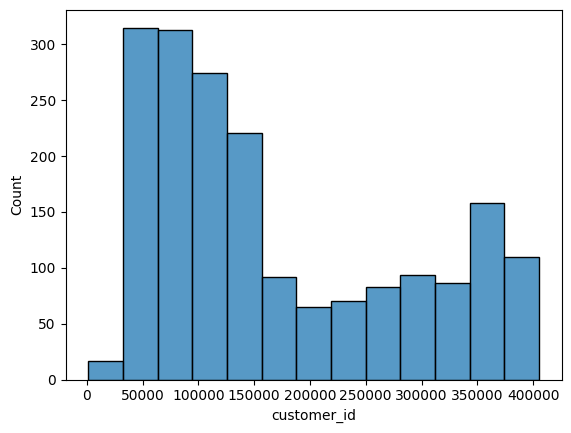

In [13]:
# Write the code here

# order_id (uniform, no plot needed)
sns.histplot(df['customer_id'], kde=False)
plt.show()


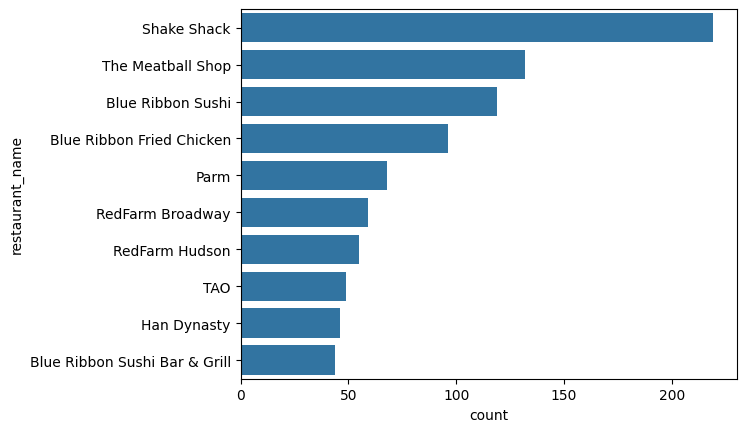

In [14]:
# Countplot for No of Restraurant

sns.countplot(y=df['restaurant_name'], order=df['restaurant_name'].value_counts().index[:10])
plt.show()

Shake Shack has the highest number count of orders.

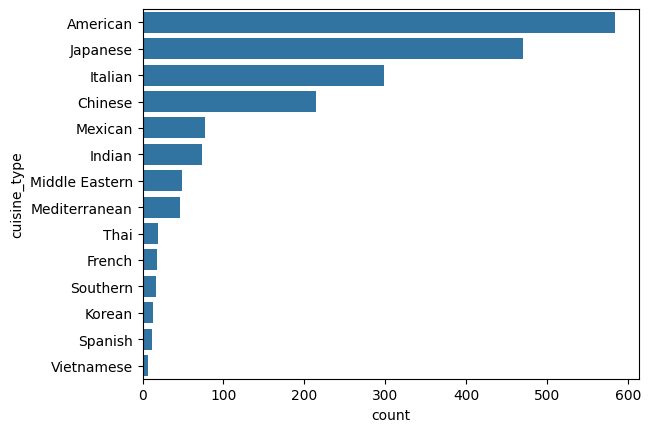

In [15]:
# Countplot for cuisine type

sns.countplot(y=df['cuisine_type'], order=df['cuisine_type'].value_counts().index)
plt.show()

American cuisine is most popular cuisine which is ordered most and followed by Japanes cuisine.

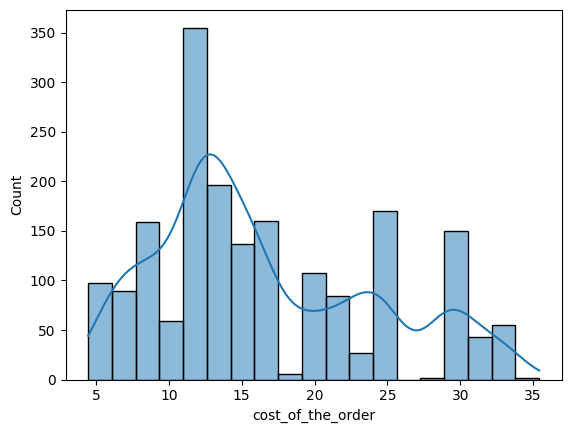

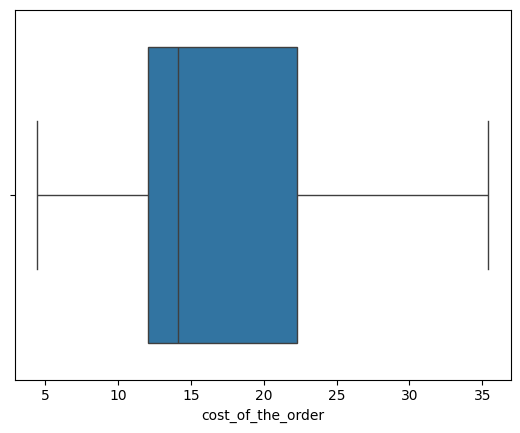

In [16]:
sns.histplot(df['cost_of_the_order'], kde=True) ## Histogram for the cost of order
plt.show()
sns.boxplot(data=df,x='cost_of_the_order') ## Boxplot for the cost of order
plt.show()

In [17]:
print("Highest cost of order value is",df['cost_of_the_order'].max())


Highest cost of order value is 35.41


Average cost of the Order is between 11 - 23 USD.Highest cost of order value is 35.41.  Boxplot median is around $14. It is right skewed means lots of order were above median


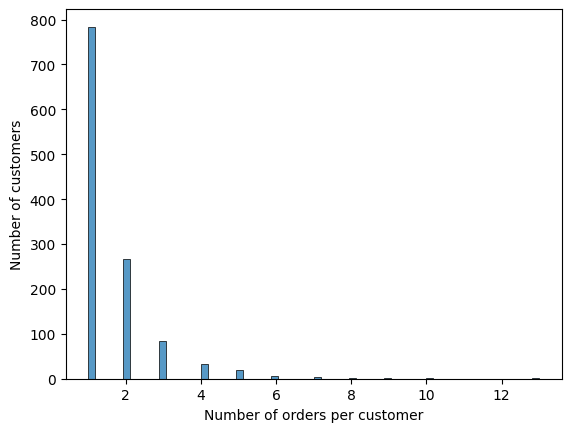

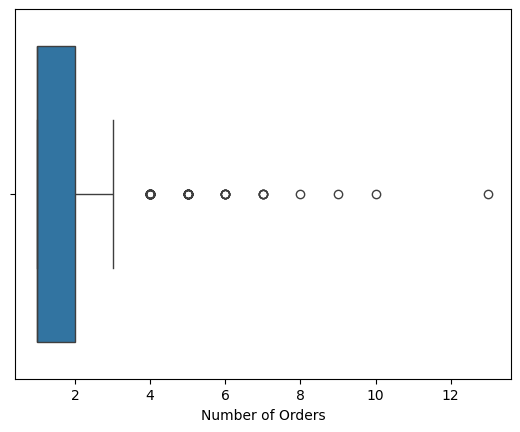

In [18]:
sns.histplot(df['customer_id'].value_counts())
plt.xlabel("Number of orders per customer")
plt.ylabel('Number of customers')
plt.show()

sns.boxplot(df,x=df['customer_id'].value_counts())
plt.xlabel("Number of Orders")

plt.show()

Most of the customers have made 1 or 2 orders. Third quartile is at 3.



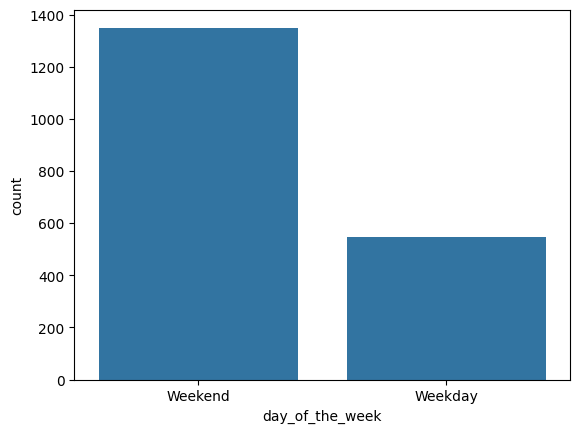

In [19]:
sns.countplot(x=df['day_of_the_week'])
plt.show()

Weekend has more orders in comparison to weekdays.

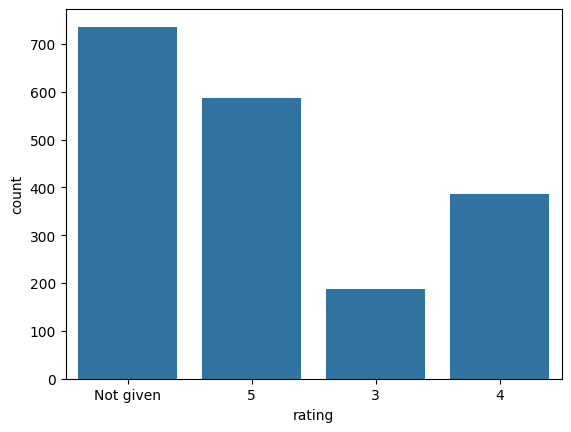

In [20]:
#code to plot a bar graph for 'rating' column
sns.countplot(data = df, x = 'rating');

Upto 700+ orders rating was Not given.Most of the orders  which got rating is 5.


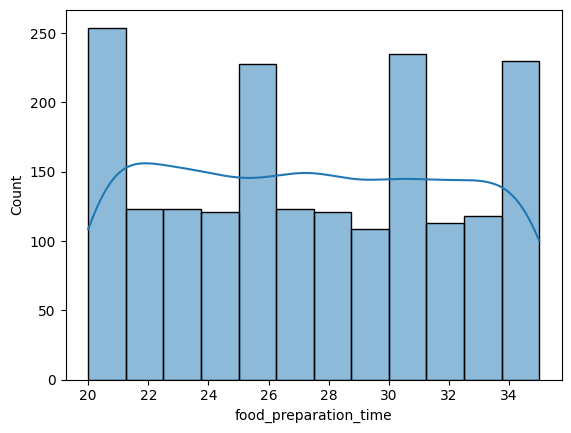

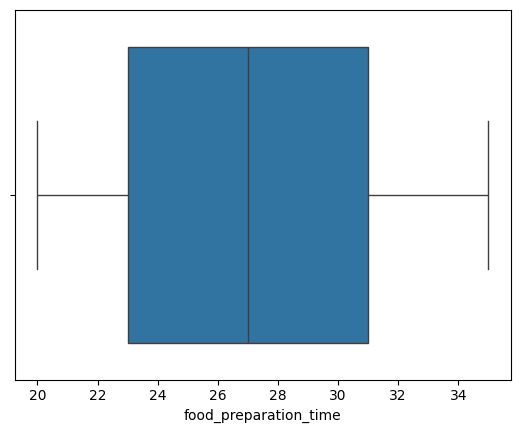

In [21]:
sns.histplot(df['food_preparation_time'], kde=True) # Histplot for Food preparation time.
plt.show()
sns.boxplot(df,x='food_preparation_time') # Boxplot for Food preparation time.
plt.show()


Median is around 27 mins.

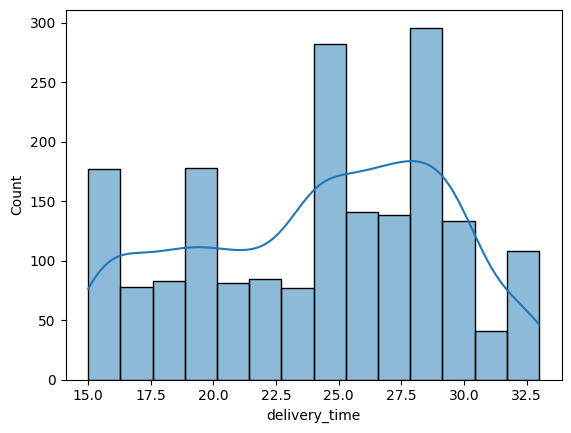

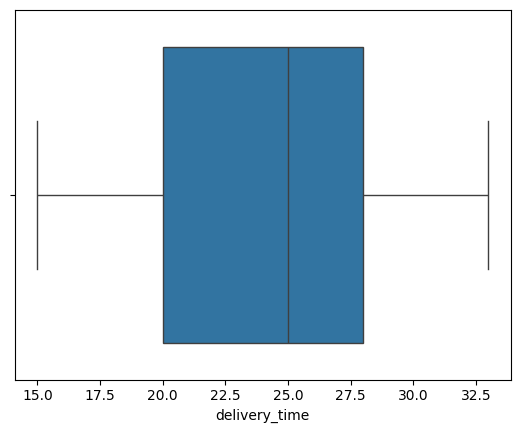

In [22]:
sns.histplot(df['delivery_time'], kde=True)
plt.show()
sns.boxplot(df,x='delivery_time')
plt.show()

Delivery time is between 15 mins to 32.5 mins. Boxplot is left skewed. Median is 25 mins. Delivery time is left skewed.



### **Question 7**: Which are the top 5 restaurants in terms of the number of orders received? [1 mark]

In [23]:
# Write the code here
df['restaurant_name'].value_counts().head(5)

,count
restaurant_name,
Shake Shack,219
The Meatball Shop,132
Blue Ribbon Sushi,119
Blue Ribbon Fried Chicken,96
Parm,68


#### Observations: Shake Shack is having most number of orders  count - 219, other 4 leading restaurants are "The Meatball Shop" with 132,"Blue Ribbon Sushi" with 119,"Blue Ribbon Fried Chicken" with 96 and "Parm" with 68 orders.


### **Question 8**: Which is the most popular cuisine on weekends? [1 mark]

In [24]:
# Write the code here
df_weekend = df[df['day_of_the_week'] == 'Weekend']
df_weekend['cuisine_type'].value_counts().idxmax()

'American'

#### Observations: American cuisine is most popular cuisine on weekends.


### **Question 9**: What percentage of the orders cost more than 20 dollars? [2 marks]

In [25]:
# Write the code here
print("Total percentage of orders costing more than $20 is",round((len(df[df['cost_of_the_order'] >=20])/len(df) )*100,1))


Total percentage of orders costing more than $20 is 29.2


#### Observations:


### **Question 10**: What is the mean order delivery time? [1 mark]

In [26]:
# Write the code here
round(df['delivery_time'].mean(),1)



np.float64(24.2)

#### Observations: Average order delivery time is 24.2 Mins.


### **Question 11:** The company has decided to give 20% discount vouchers to the top 3 most frequent customers. Find the IDs of these customers and the number of orders they placed. [1 mark]

In [27]:
# Write the code here
df['customer_id'].value_counts().head(3)

,count
customer_id,
52832,13
47440,10
83287,9


#### Observations: : Top three frequent customers are "52832","47440" and "83287".


### Multivariate Analysis

### **Question 12**: Perform a multivariate analysis to explore relationships between the important variables in the dataset. (It is a good idea to explore relations between numerical variables as well as relations between numerical and categorical variables) [10 marks]


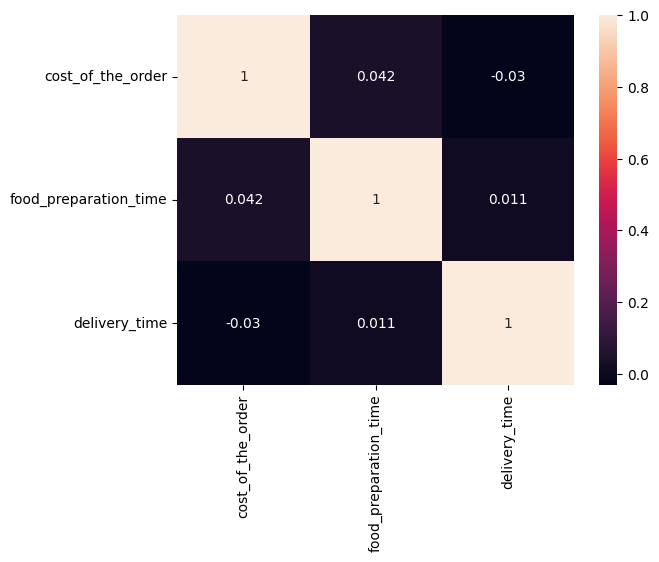

In [28]:
# Write the code here
# Numerical correlations
numerical_cols = ['cost_of_the_order', 'food_preparation_time', 'delivery_time']
sns.heatmap(df[numerical_cols].corr(), annot=True)
plt.show()

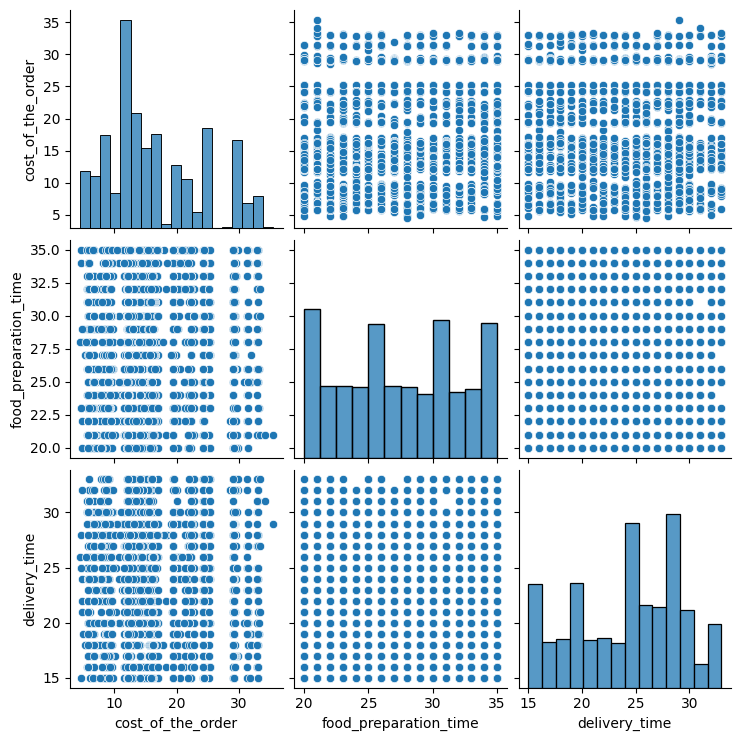

In [29]:
# Pairplot
sns.pairplot(df[numerical_cols])
plt.show()

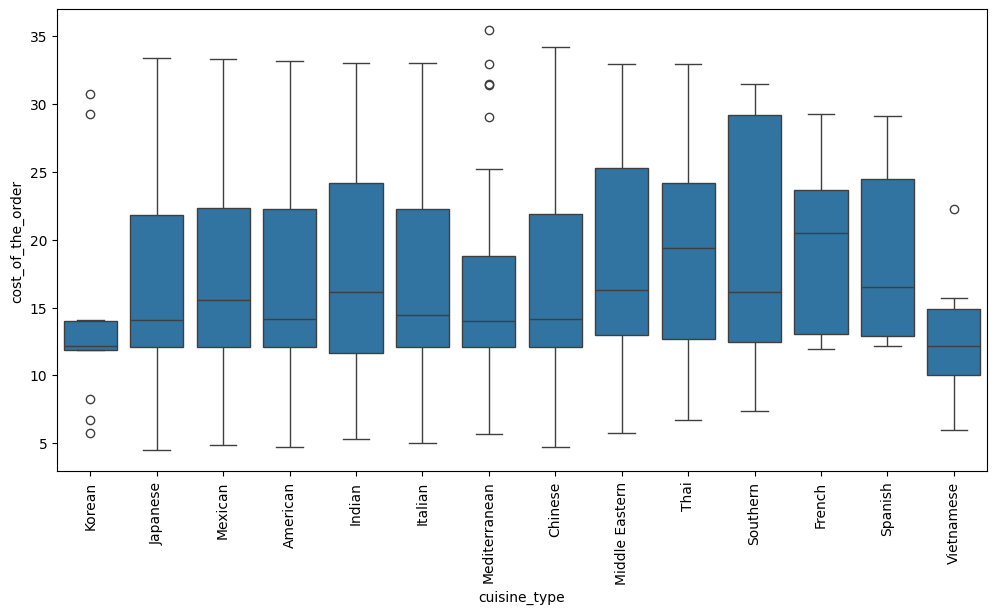

In [30]:
# Boxplot: cost by cuisine_type
plt.figure(figsize=(12,6))
sns.boxplot(x='cuisine_type', y='cost_of_the_order', data=df)
plt.xticks(rotation=90)
plt.show()

There are few outliers for Korean,Mediterreann and Vietnamese. French cuisine has highest average cost.

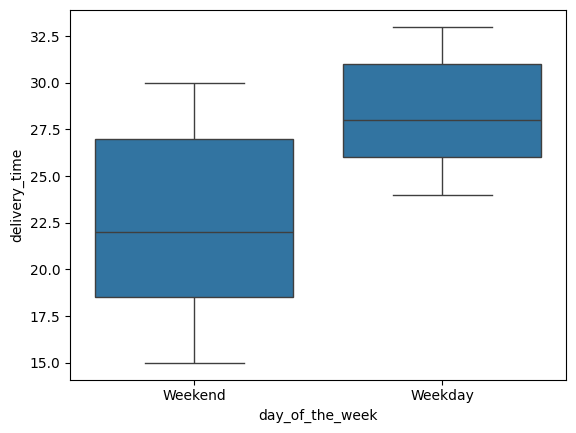

In [31]:
# Boxplot: delivery_time by day_of_the_week
sns.boxplot(x='day_of_the_week', y='delivery_time', data=df)
plt.show()

Delivery takes longer time during the weekends. The median delivery time for weekends is ~22.5 minutes while for the weekdays is ~28.5 minutes



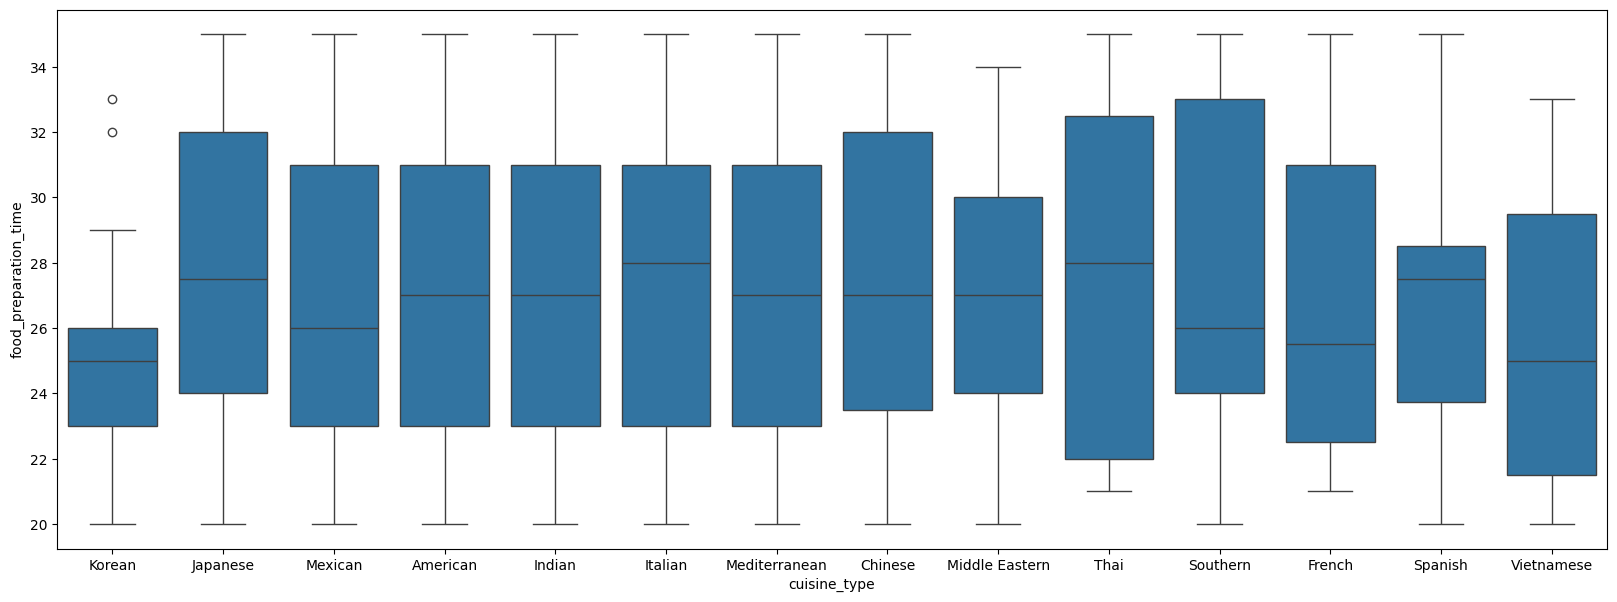

In [32]:
plt.figure(figsize =(20,7))
sns.boxplot(df, x='cuisine_type',y='food_preparation_time')
plt.show()

Most of cuisines have similar average preparation time except Korean, Spanish, Middle eastern and southern.



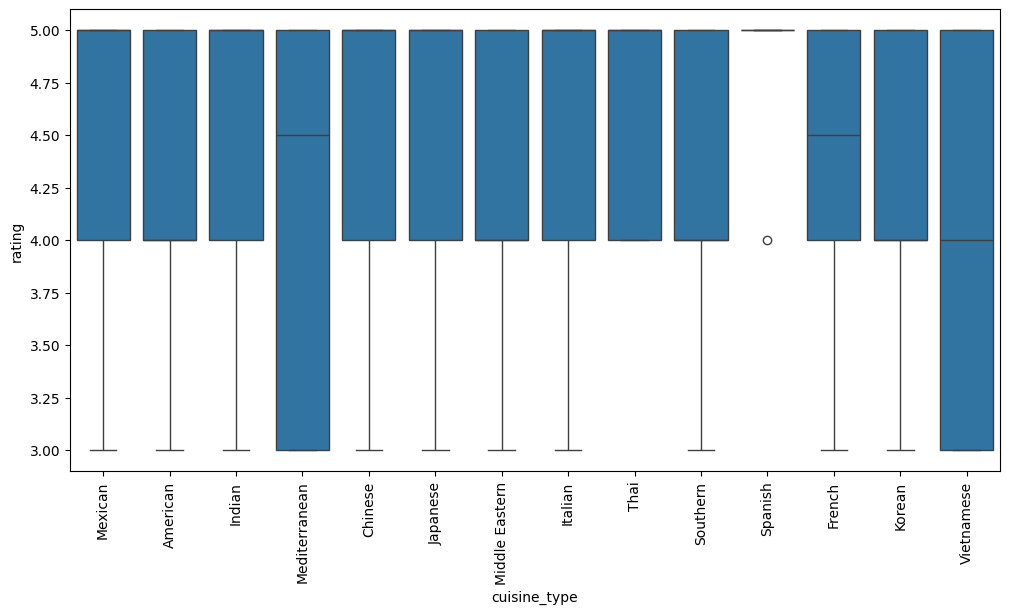

In [33]:
# Rating (convert to numeric)
df_rated = df[df['rating'] != 'Not given'].copy()
df_rated['rating'] = df_rated['rating'].astype(float)

# Boxplot: rating by cuisine_type
plt.figure(figsize=(12,6))
sns.boxplot(x='cuisine_type', y='rating', data=df_rated)
plt.xticks(rotation=90)
plt.show()

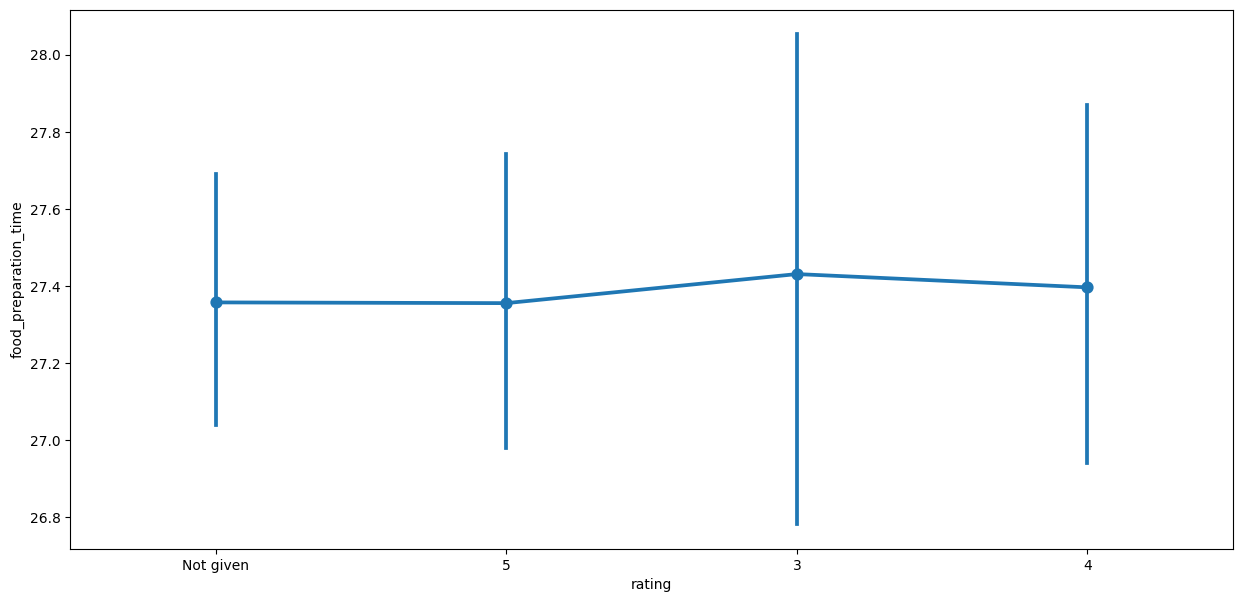

In [34]:
plt.figure(figsize=(15, 7))
sns.pointplot( df, x = 'rating', y = 'food_preparation_time')
plt.show()

Most of orders have same preparation time and rating is not impacted due to preparation time.

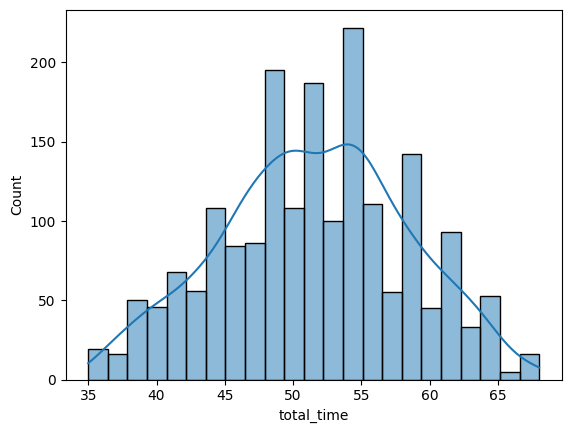

In [35]:
# Total time
df['total_time'] = df['food_preparation_time'] + df['delivery_time']
sns.histplot(df['total_time'], kde=True)
plt.show()

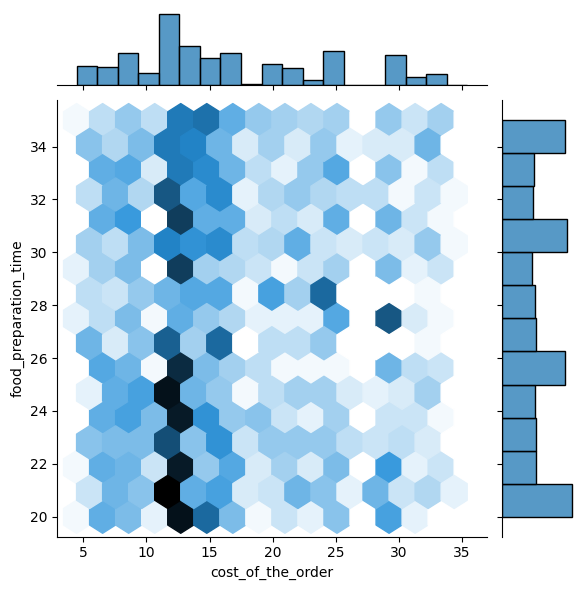

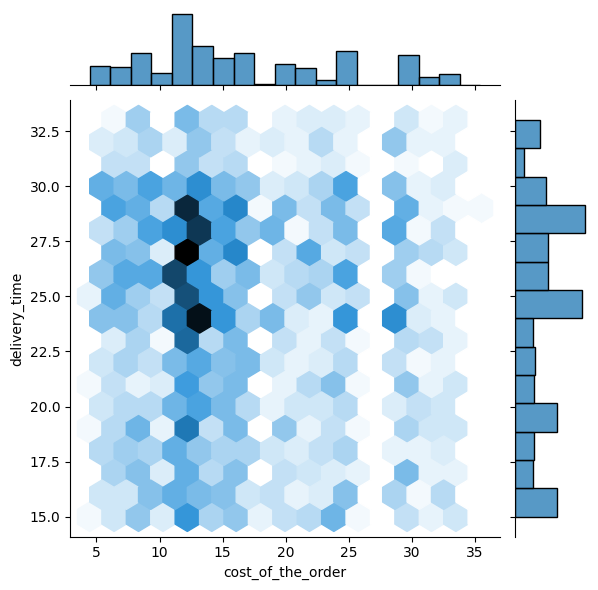

In [36]:
sns.jointplot(data = df, x = 'cost_of_the_order', y = 'food_preparation_time',kind = 'hex')
plt.show()

sns.jointplot(data = df, x = 'cost_of_the_order', y = 'delivery_time', kind = 'hex')
plt.show()

Cost of the Order vs Food Preparation time -> most of the orders are of 11 USD. Its spanning over all food preparation time. Cost of the oder vs Delivery time -> for orders of ~$11 delivery time is 23 to 29 mins,

### **Question 13:** The company wants to provide a promotional offer in the advertisement of the restaurants. The condition to get the offer is that the restaurants must have a rating count of more than 50 and the average rating should be greater than 4. Find the restaurants fulfilling the criteria to get the promotional offer. [3 marks]

In [43]:
# Write the code here
df_rated = df[df['rating'] != 'Not given'].copy()
df_rated['rating'] = df_rated['rating'].astype(float)
grouped = df_rated.groupby('restaurant_name')['rating'].agg(['count', 'mean'])
grouped[(grouped['count'] > 50) & (grouped['mean'] > 4)]

,count,mean
restaurant_name,,
Blue Ribbon Fried Chicken,64,4.328125
Blue Ribbon Sushi,73,4.219178
Shake Shack,133,4.278195
The Meatball Shop,84,4.511905


#### Observations: Four Restaurants "The Meatball Shop Blue" ,"Blue Ribbon Fried Chicken","Shake Shack", and "Blue Ribbon Sushi" qualify for the promotional offer which fulfill the criteria.


### **Question 14:** The company charges the restaurant 25% on the orders having cost greater than 20 dollars and 15% on the orders having cost greater than 5 dollars. Find the net revenue generated by the company across all orders. [3 marks]

In [39]:
# Write the code here

def calculate_revenue(cost):
    if cost > 20:
        return cost * 0.25
    elif cost > 5:
        return cost * 0.15
    else:
        return 0

df['revenue'] = df['cost_of_the_order'].apply(calculate_revenue)
df['revenue'].sum()

np.float64(6166.303)

#### Observations: Company is generating the $6166.303 revenue across all orders.


### **Question 15:** The company wants to analyze the total time required to deliver the food. What percentage of orders take more than 60 minutes to get delivered from the time the order is placed? (The food has to be prepared and then delivered.) [2 marks]

In [38]:
# Write the code here

df['total_time'] = df['food_preparation_time'] + df['delivery_time']
((df['total_time'] > 60).sum() / len(df)) * 100

np.float64(10.537407797681771)

#### Observations: 10.5% orders takes more than 60 minutes to get delivered from the time the order is placed.


### **Question 16:** The company wants to analyze the delivery time of the orders on weekdays and weekends. How does the mean delivery time vary during weekdays and weekends? [2 marks]

In [44]:
# Write the code here

df.groupby('day_of_the_week')['delivery_time'].mean()

,delivery_time
day_of_the_week,
Weekday,28.340037
Weekend,22.470022


#### Observations: Delivery is faster on weekend compared to weekdays. On Weekdays Delivery time is around 28 mins and on weekend it is around 22 mins


### Conclusion and Recommendations

### **Question 17:** What are your conclusions from the analysis? What recommendations would you like to share to help improve the business? (You can use cuisine type and feedback ratings to drive your business recommendations.) [6 marks]

### Conclusions:
* High demand on weekends; American cuisine most popular and Japanese after that.
* Many orders unrated; delivery times higher on weekdays
* Top restaurants like Shake Shack dominate orders
* ~29% orders >$20; ~10% total time >60 min.
* Korean and Vietnamese are the cheapest cuisine.

### Recommendations:

* Promote high-rated cuisines like American/Japanese/Italian
* Encourage ratings via incentives.
* Partner with top restaurants
* Optimize delivery on weekdays
* Focus ads on popular cuisines for better engagement.
* Weekdays should have more offers to increase the sale.

---